In [1]:
# ======================================================
# JOUR 4 (fin) / JOUR 5
# Doublons – Incohérences – Normalisation – Ratios
# ======================================================

import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# 1️⃣ Charger le dataset nettoyé (après option 1, 2 ou 3)
df = pd.read_csv("ensp_dataset_5000_clean.csv")

print("✅ Dataset chargé")
print(df.head())

# ======================================================
# 2️⃣ VÉRIFICATION DES DOUBLONS
# ======================================================

# Doublons complets
doublons = df.duplicated()
print("\n🔁 Nombre de lignes dupliquées :", doublons.sum())

# Supprimer les doublons 
df = df.drop_duplicates()

print("Dimensions après suppression des doublons :", df.shape)

# ======================================================
# 3️⃣ DÉTECTION DES INCOHÉRENCES
# ======================================================

# Âge incohérent (trop jeune ou trop âgé)
age_incoherent = df[(df['age'] < 17) | (df['age'] > 35)]
print("\n⚠️ Étudiants avec âge incohérent :", age_incoherent.shape[0])

# Notes incohérentes
notes_cols = ['assignments_avg', 'midterm_score', 'final_score', 'overall_grade']
notes_incoherentes = df[
    (df[notes_cols] < 0).any(axis=1) |
    (df[notes_cols] > 100).any(axis=1)
]
print("⚠️ Lignes avec notes incohérentes :", notes_incoherentes.shape[0])

# Présence incohérente
presence_incoherente = df[(df['attendance_rate'] < 0) | (df['attendance_rate'] > 100)]
print("⚠️ Présence incohérente :", presence_incoherente.shape[0])

# Option : supprimer les lignes incohérentes
df = df[
    (df['age'] >= 17) & (df['age'] <= 35) &
    (df['attendance_rate'] >= 0) & (df['attendance_rate'] <= 100)
]

print("Dimensions après suppression des incohérences :", df.shape)

# ======================================================
# 4️⃣ NORMALISATION DES SCORES
# ======================================================

notes_a_normaliser = [
    'assignments_avg',
    'midterm_score',
    'final_score',
    'overall_grade',
    'attendance_rate'
]

# Min-Max Scaling (0 à 1)
scaler = MinMaxScaler()
df_norm = df.copy()
df_norm[notes_a_normaliser] = scaler.fit_transform(df[notes_a_normaliser])

print("\n✅ Normalisation Min-Max terminée")

# ======================================================
# 5️⃣ CRÉATION DE RATIOS PERTINENTS
# ======================================================

# Ratio présence / note globale
df_norm['ratio_presence_note'] = (
    df_norm['attendance_rate'] / (df_norm['overall_grade'] + 1e-5)
)

# Moyenne des examens
df_norm['moyenne_examens'] = (
    df_norm['midterm_score'] + df_norm['final_score']
) / 2

# Engagement académique (projets + heures labo)
df_norm['engagement_academique'] = (
    df_norm['project_participation'] +
    df_norm['lab_hours_per_week']
)

print("\n📊 Nouvelles variables créées :")
print(df_norm[['ratio_presence_note', 'moyenne_examens', 'engagement_academique']].head())

# ======================================================
# 6️⃣ SAUVEGARDE DU DATASET FINAL
# ======================================================

df_norm.to_csv("dataset_final_pret_ML.csv", index=False)

print("\n📁 Dataset final sauvegardé : dataset_final_pret_ML.csv")


✅ Dataset chargé
    student_id  gender   age       filiere  year_of_study  attendance_rate  \
0  ENSPD000001    Male  21.0     Mecanique              5             85.8   
1  ENSPD000002  Female  17.0  Informatique              4             80.8   
2  ENSPD000003  Female  21.0   Energetique              4             85.5   
3  ENSPD000004  Female  24.0     Mecanique              2            100.0   
4  ENSPD000005    Male  23.0    GenieCivil              1             93.0   

   num_absences  assignments_avg  midterm_score  final_score  ...  \
0          14.0             78.6           85.5         80.6  ...   
1          19.0             85.1           82.6          5.7  ...   
2          14.0             60.4           61.6         72.8  ...   
3           0.0             47.2           60.4         67.2  ...   
4           7.0             47.3           65.2         26.3  ...   

   infra_usage_hours_month  supervisor_assigned  scholarship  \
0                     12.9         

✅ Dataset final chargé


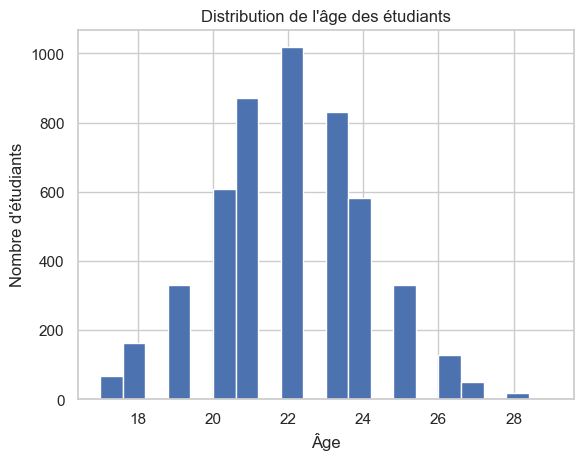

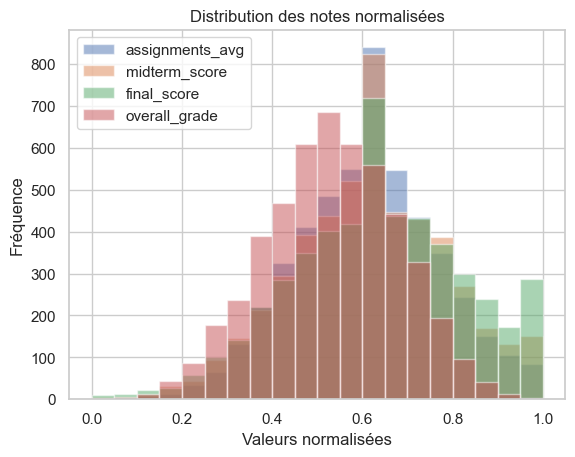

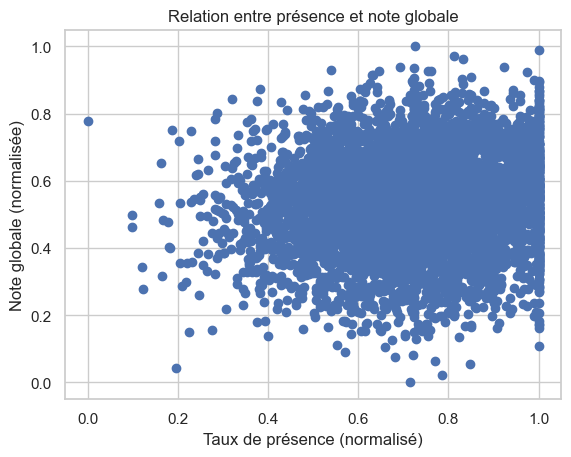

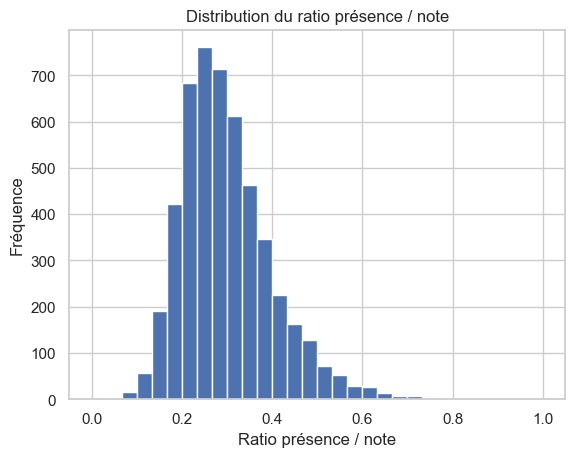

In [4]:
# ======================================================
# VISUALISATIONS – Doublons – Incohérences – Normalisation – Ratios
# ======================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Style simple
sns.set(style="whitegrid")

# ======================================================
# 1️⃣ Charger le dataset final
# ======================================================

df = pd.read_csv("dataset_final_pret_ML.csv")
print("✅ Dataset final chargé")

# ======================================================
# 2️⃣ DISTRIBUTION DE L’ÂGE
# ======================================================

plt.figure()
plt.hist(df['age'], bins=20)
plt.xlabel("Âge")
plt.ylabel("Nombre d'étudiants")
plt.title("Distribution de l'âge des étudiants")
plt.show()

# ======================================================
# 3️⃣ DISTRIBUTION DES NOTES NORMALISÉES
# ======================================================

notes = [
    'assignments_avg',
    'midterm_score',
    'final_score',
    'overall_grade'
]

plt.figure()
for col in notes:
    plt.hist(df[col], bins=20, alpha=0.5, label=col)

plt.xlabel("Valeurs normalisées")
plt.ylabel("Fréquence")
plt.title("Distribution des notes normalisées")
plt.legend()
plt.show()

# ======================================================
# 4️⃣ PRÉSENCE VS NOTE GLOBALE
# ======================================================

plt.figure()
plt.scatter(df['attendance_rate'], df['overall_grade'])
plt.xlabel("Taux de présence (normalisé)")
plt.ylabel("Note globale (normalisée)")
plt.title("Relation entre présence et note globale")
plt.show()

# ======================================================
# 5️⃣ RATIO PRÉSENCE / NOTE
# ======================================================

plt.figure()
plt.hist(df['ratio_presence_note'], bins=30)
plt.xlabel("Ratio présence / note")
plt.ylabel("Fréquence")
plt.title("Distribution du ratio présence / note")
plt.show()



